# SHMS Transport-Residual MLP（脱离 ROOT 重建）

本笔记本实现一个 **不依赖 ROOT 重建结果作为训练 baseline** 的 ResMLP 方案。

核心结构：

- 线性主干：学习 spectrometer 的零阶 / 一阶线性 transport
- 残差分支：利用 skip connection 学习高阶非线性修正项
- 最终输出：$y = y_{\text{linear}} + y_{\text{nonlinear}}$

设计动机：

1. **Perturbation Learning**：让网络集中学习 fringe field / aberration 等高阶非线性，而不是从头重学线性 optics。
2. **Gradient Flow**：残差块的 skip connection 改善深层网络训练稳定性。
3. **脱离 ROOT 重建**：ROOT reco 仅作为后验对比基线，不参与训练目标构造。

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from datetime import datetime
from typing import Any
import math
import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import uproot
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


In [2]:
# ===== 配置区（按需修改） =====
ROOT_FILE = Path('C:\\Users\\Lanto\\Desktop\\AI_ML R-SIDIS\\mc-single-arm\\worksim\\shms_extended_nosieve.root')
INP_FILE = Path('C:\\Users\\Lanto\\Desktop\\AI_ML R-SIDIS\\mc-single-arm\\infiles\\shms_extended_nosieve.inp')

TREE_NAME = 'h10'
TARGET_MODE = 'all'  # 'core3' | 'all' | 'delta-only'
FILTER_STOP_ID = True
MAX_EVENTS = 100_000
VAL_FRACTION = 0.20
EPOCHS = 80
BATCH_SIZE = 2048
LR = 8e-4
WEIGHT_DECAY = 1e-4
SEED = 42

# 输入特征
INCLUDE_FRY = True
FRY_BRANCH: str | None = 'fry'

# 结构超参数
MODEL_HIDDEN = 192
MODEL_BLOCKS = 4
DROPOUT = 0.10
GRAD_CLIP_NORM = 1.0

# 训练策略
INIT_LINEAR_WITH_LEAST_SQUARES = True
LINEAR_INIT_RIDGE = 1e-6
EARLY_STOPPING_PATIENCE = 15
EARLY_STOPPING_MIN_DELTA = 5e-5
SCHEDULER_PATIENCE = 5
SCHEDULER_FACTOR = 0.5
MIN_LR = 1e-5
LINEAR_WARMUP_EPOCHS = 10
FREEZE_LINEAR_AFTER_WARMUP = True
LINEAR_AUX_WEIGHT = 0.0
CORRECTION_L2_WEIGHT = 1e-4

# 多任务 loss 权重：ytar 仍适当降权，避免训练初期主导共享表示
TARGET_LOSS_WEIGHTS = {
    'delta': 1.0,
    'xptar': 1.0,
    'yptar': 1.0,
    'ytar': 0.50,
}

# 诊断
RUN_NONLINEAR_DIAGNOSTICS = True
COMPARE_TO_ROOT_RECO = True

P0_OVERRIDE: float | None = None
X_TAR_MODE = 'zero'  # 'zero' | 'random'
X_TAR_SIGMA = 0.1

OUTPUT_DIR = Path('outputs_transport_skip')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT_FILE =', ROOT_FILE.resolve())
print('INP_FILE  =', INP_FILE.resolve() if INP_FILE.exists() else '(not found)')
print('OUTPUT_DIR =', OUTPUT_DIR.resolve())
print('Feature config =', {'include_fry': INCLUDE_FRY, 'fry_branch': FRY_BRANCH})
print('Model config =', {'hidden': MODEL_HIDDEN, 'blocks': MODEL_BLOCKS, 'dropout': DROPOUT})
print(
    'Training config =',
    {
        'init_linear_with_least_squares': INIT_LINEAR_WITH_LEAST_SQUARES,
        'linear_init_ridge': LINEAR_INIT_RIDGE,
        'warmup_epochs': LINEAR_WARMUP_EPOCHS,
        'freeze_linear_after_warmup': FREEZE_LINEAR_AFTER_WARMUP,
        'linear_aux_weight': LINEAR_AUX_WEIGHT,
        'correction_l2_weight': CORRECTION_L2_WEIGHT,
    },
)
print('Loss weights =', TARGET_LOSS_WEIGHTS)

ROOT_FILE = C:\Users\Lanto\Desktop\AI_ML R-SIDIS\mc-single-arm\worksim\shms_extended_nosieve.root
INP_FILE  = C:\Users\Lanto\Desktop\AI_ML R-SIDIS\mc-single-arm\infiles\shms_extended_nosieve.inp
OUTPUT_DIR = C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\ResMLP\outputs_transport_skip
Feature config = {'include_fry': True, 'fry_branch': 'fry'}
Model config = {'hidden': 192, 'blocks': 4, 'dropout': 0.1}
Training config = {'init_linear_with_least_squares': True, 'linear_init_ridge': 1e-06, 'warmup_epochs': 10, 'freeze_linear_after_warmup': True, 'linear_aux_weight': 0.0, 'correction_l2_weight': 0.0001}
Loss weights = {'delta': 1.0, 'xptar': 1.0, 'yptar': 1.0, 'ytar': 0.5}


In [3]:
def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)


def detect_prefix(branches: list[str]) -> str:
    for pref in ['ps', 'hs']:
        required = [f'{pref}xfp', f'{pref}yfp', f'{pref}xpfp', f'{pref}ypfp', f'{pref}deltai']
        if all(r in branches for r in required):
            return pref
    raise RuntimeError('Cannot detect branch prefix. Expected ps* or hs* branches.')


def resolve_fry_branch(branches: list[str], pref: str, requested_branch: str | None) -> str:
    candidates = [requested_branch] if requested_branch else ['fry', f'{pref}fry']
    for candidate in candidates:
        if candidate and candidate in branches:
            return candidate
    raise RuntimeError(
        'Requested fry feature, but no fry branch was found. Checked: '
        + ', '.join([c for c in candidates if c])
    )


def infer_p0_from_inp(inp_file: Path) -> float | None:
    if not inp_file.exists():
        return None
    target_keywords = ('Spectrometer central momentum', 'Spectrometer momentum')
    for line in inp_file.read_text(encoding='utf-8', errors='ignore').splitlines():
        if any(k in line for k in target_keywords):
            for token in line.replace(',', ' ').split():
                try:
                    p0_mev = float(token)
                    return p0_mev / 1000.0
                except ValueError:
                    continue
    return None


def infer_reco_branch(pref: str, truth_branch: str, all_branches: list[str]) -> str | None:
    stripped = truth_branch[len(pref):] if truth_branch.startswith(pref) else truth_branch
    candidates: list[str] = []

    manual = {
        'deltai': [f'{pref}delta', f'{pref}deltar'],
        'xptari': [f'{pref}xptar'],
        'yptari': [f'{pref}yptar'],
        'ztari': [f'{pref}ztar', f'{pref}ytar'],
    }
    if stripped in manual:
        candidates.extend(manual[stripped])

    if stripped.endswith('i'):
        candidates.append(f'{pref}{stripped[:-1]}')

    for c in candidates:
        if c in all_branches:
            return c
    return None


def align_reco_to_truth(
    pref: str,
    truth_branch: str,
    reco_branch: str | None,
    reco_values: np.ndarray,
    ) -> tuple[np.ndarray, str | None]:
    if reco_branch is None:
        return reco_values, None

    if truth_branch == f'{pref}ztari' and reco_branch in {f'{pref}ztar', f'{pref}ytar'}:
        return -reco_values, f'-{reco_branch}'

    return reco_values, reco_branch


@dataclass
class DataBundle:
    X: np.ndarray
    Y: np.ndarray
    Y_reco: np.ndarray
    feature_names: list[str]
    target_names: list[str]
    target_truth_branches: list[str]
    target_reco_branches: list[str | None]
    prefix: str
    n_all: int
    n_after_filter: int


def load_data(
    root_file: Path,
    tree_name: str,
    target_mode: str,
    p0: float,
    include_fry: bool,
    fry_branch: str | None,
    x_tar_mode: str,
    x_tar_sigma: float,
    max_events: int,
    seed: int,
    filter_stop_id: bool,
    ) -> DataBundle:
    rf: Any = uproot.open(root_file)
    tree = rf[tree_name]
    branches = list(tree.keys())

    pref = detect_prefix(branches)
    input_branches = [f'{pref}xfp', f'{pref}yfp', f'{pref}xpfp', f'{pref}ypfp']
    resolved_fry_branch = resolve_fry_branch(branches, pref, fry_branch) if include_fry else None

    if target_mode == 'all':
        target_branches = [f'{pref}deltai', f'{pref}xptari', f'{pref}yptari', f'{pref}ztari']
        target_names = ['delta', 'xptar', 'yptar', 'ytar']
    elif target_mode == 'core3':
        target_branches = [f'{pref}deltai', f'{pref}xptari', f'{pref}yptari']
        target_names = ['delta', 'xptar', 'yptar']
    elif target_mode == 'delta-only':
        target_branches = [f'{pref}deltai']
        target_names = ['delta']
    else:
        raise ValueError("TARGET_MODE must be one of: 'core3', 'all', 'delta-only'")

    raw_target_reco_branches = [infer_reco_branch(pref, tb, branches) for tb in target_branches]
    reco_existing = [b for b in raw_target_reco_branches if b is not None]

    wanted = input_branches + ([resolved_fry_branch] if resolved_fry_branch else []) + target_branches + reco_existing + (['stop_id'] if filter_stop_id else [])
    arr = tree.arrays(wanted, library='np')
    rf.close()

    n_all = len(arr[input_branches[0]])
    n = min(n_all, max_events) if max_events is not None else n_all

    X_raw = np.column_stack([arr[b][:n].astype(np.float32) for b in input_branches])
    feature_names = ['x_fp', 'y_fp', 'xp_fp', 'yp_fp']
    if resolved_fry_branch is not None:
        fry_col = arr[resolved_fry_branch][:n].astype(np.float32).reshape(-1, 1)
        X_raw = np.concatenate([X_raw, fry_col], axis=1)
        feature_names.append('fry')
    Y_raw = np.column_stack([arr[b][:n].astype(np.float32) for b in target_branches])

    reco_cols: list[np.ndarray] = []
    target_reco_branches: list[str | None] = []
    for truth_branch, rb in zip(target_branches, raw_target_reco_branches):
        if rb is not None and rb in arr:
            reco_values, reco_label = align_reco_to_truth(
                pref=pref,
                truth_branch=truth_branch,
                reco_branch=rb,
                reco_values=arr[rb][:n].astype(np.float32),
            )
            reco_cols.append(reco_values)
            target_reco_branches.append(reco_label)
        else:
            reco_cols.append(np.full(n, np.nan, dtype=np.float32))
            target_reco_branches.append(rb)
    Y_reco_raw = np.column_stack(reco_cols)

    mask = np.isfinite(X_raw).all(axis=1) & np.isfinite(Y_raw).all(axis=1)
    if filter_stop_id:
        mask &= (arr['stop_id'][:n] == 0)

    X_raw = X_raw[mask]
    Y_raw = Y_raw[mask]
    Y_reco = Y_reco_raw[mask]
    n_after_filter = int(mask.sum())

    if x_tar_mode == 'random':
        rng = np.random.default_rng(seed)
        x_tar = rng.normal(0.0, x_tar_sigma, size=(n_after_filter, 1)).astype(np.float32)
    elif x_tar_mode == 'zero':
        x_tar = np.zeros((n_after_filter, 1), dtype=np.float32)
    else:
        raise ValueError("X_TAR_MODE must be 'zero' or 'random'")

    p0_col = np.full((n_after_filter, 1), p0, dtype=np.float32)
    X = np.concatenate([X_raw, x_tar, p0_col], axis=1)
    feature_names.extend(['x_tar', 'p0'])

    return DataBundle(
        X=X,
        Y=Y_raw,
        Y_reco=Y_reco,
        feature_names=feature_names,
        target_names=target_names,
        target_truth_branches=target_branches,
        target_reco_branches=target_reco_branches,
        prefix=pref,
        n_all=n_all,
        n_after_filter=n_after_filter,
    )

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.0):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.act = nn.SiLU()
        self.fc2 = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.fc1(x)
        h = self.act(h)
        h = self.drop(h)
        h = self.fc2(h)
        return self.act(x + h)


class ResidualTransportMLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden: int = 256, n_blocks: int = 4, dropout: float = 0.0):
        super().__init__()
        self.linear_path = nn.Linear(in_dim, out_dim)
        self.residual_input = nn.Sequential(nn.Linear(in_dim, hidden), nn.SiLU())
        self.blocks = nn.Sequential(*[ResidualBlock(hidden, dropout=dropout) for _ in range(n_blocks)])
        self.correction_head = nn.Linear(hidden, out_dim)
        nn.init.zeros_(self.correction_head.weight)
        nn.init.zeros_(self.correction_head.bias)

    def forward(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        linear = self.linear_path(x)
        h = self.residual_input(x)
        h = self.blocks(h)
        correction = self.correction_head(h)
        total = linear + correction
        return {'total': total, 'linear': linear, 'correction': correction}

    def freeze_residual_branch(self) -> None:
        for module in [self.residual_input, self.blocks, self.correction_head]:
            for param in module.parameters():
                param.requires_grad = False
        for param in self.linear_path.parameters():
            param.requires_grad = True

    def unfreeze_residual_branch(self) -> None:
        for module in [self.residual_input, self.blocks, self.correction_head]:
            for param in module.parameters():
                param.requires_grad = True

    def freeze_linear_path(self) -> None:
        for param in self.linear_path.parameters():
            param.requires_grad = False

    def unfreeze_all(self) -> None:
        for param in self.parameters():
            param.requires_grad = True


def build_target_weight_vector(target_names: list[str], target_loss_weights: dict[str, float] | None) -> np.ndarray:
    if target_loss_weights is None:
        return np.ones(len(target_names), dtype=np.float32)
    return np.array([float(target_loss_weights.get(name, 1.0)) for name in target_names], dtype=np.float32)


def safe_corrcoef(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    if a.size == 0 or b.size == 0:
        return float('nan')
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return float('nan')
    return float(np.corrcoef(a, b)[0, 1])


def compute_error_metrics(pred: np.ndarray, truth: np.ndarray) -> dict[str, Any]:
    err = pred - truth
    n_targets = truth.shape[1]
    rmse = np.full(n_targets, np.nan, dtype=np.float64)
    mae = np.full(n_targets, np.nan, dtype=np.float64)
    bias = np.full(n_targets, np.nan, dtype=np.float64)
    resid_std = np.full(n_targets, np.nan, dtype=np.float64)
    rel_rmse = np.full(n_targets, np.nan, dtype=np.float64)
    rel_mae = np.full(n_targets, np.nan, dtype=np.float64)

    for i in range(n_targets):
        mask = np.isfinite(pred[:, i]) & np.isfinite(truth[:, i])
        if not np.any(mask):
            continue
        e = err[mask, i]
        y = truth[mask, i]
        rmse[i] = np.sqrt(np.mean(np.square(e)))
        mae[i] = np.mean(np.abs(e))
        bias[i] = np.mean(e)
        resid_std[i] = np.std(e)
        scale = max(np.mean(np.abs(y)), 1e-8)
        rel_rmse[i] = rmse[i] / scale
        rel_mae[i] = mae[i] / scale

    return {
        'err': err,
        'rmse': rmse,
        'mae': mae,
        'bias': bias,
        'resid_std': resid_std,
        'rel_rmse': rel_rmse,
        'rel_mae': rel_mae,
    }


def split_linear_and_correction(scaler_y: StandardScaler, pred_linear_s: np.ndarray, pred_corr_s: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    scale = np.asarray(scaler_y.scale_, dtype=np.float64).reshape(1, -1)
    mean = np.asarray(scaler_y.mean_, dtype=np.float64).reshape(1, -1)
    linear_part = mean + pred_linear_s * scale
    correction_part = pred_corr_s * scale
    total = linear_part + correction_part
    return linear_part, correction_part, total


def fit_linear_transport_init(X_train_s: np.ndarray, y_train_s: np.ndarray, ridge: float = 1e-6) -> tuple[np.ndarray, np.ndarray]:
    ones = np.ones((X_train_s.shape[0], 1), dtype=np.float64)
    design = np.concatenate([X_train_s.astype(np.float64), ones], axis=1)
    lhs = design.T @ design
    reg = np.eye(lhs.shape[0], dtype=np.float64) * ridge
    reg[-1, -1] = 0.0
    rhs = design.T @ y_train_s.astype(np.float64)
    beta = np.linalg.solve(lhs + reg, rhs)
    weight = beta[:-1, :].T.astype(np.float32)
    bias = beta[-1, :].astype(np.float32)
    return weight, bias


def run_training(
    X: np.ndarray,
    Y: np.ndarray,
    target_names: list[str],
    val_fraction: float,
    epochs: int,
    batch_size: int,
    lr: float,
    weight_decay: float,
    seed: int,
    hidden: int = 256,
    n_blocks: int = 4,
    dropout: float = 0.0,
    target_loss_weights: dict[str, float] | None = None,
    grad_clip_norm: float | None = None,
    early_stopping_patience: int | None = None,
    early_stopping_min_delta: float = 0.0,
    scheduler_patience: int = 5,
    scheduler_factor: float = 0.5,
    min_lr: float = 1e-5,
    init_linear_with_least_squares: bool = True,
    linear_init_ridge: float = 1e-6,
    linear_warmup_epochs: int = 0,
    freeze_linear_after_warmup: bool = False,
    linear_aux_weight: float = 0.0,
    correction_l2_weight: float = 0.0,
) -> dict[str, Any]:
    idx_all = np.arange(len(X), dtype=np.int64)
    X_train, X_val, y_train, y_val, _, idx_val = train_test_split(
        X, Y, idx_all, test_size=val_fraction, random_state=seed, shuffle=True
    )

    n_train = len(X_train)

    sx = StandardScaler().fit(X_train)
    sy = StandardScaler().fit(y_train)

    X_train_s = sx.transform(X_train).astype(np.float32)
    X_val_s = sx.transform(X_val).astype(np.float32)
    y_train_s = sy.transform(y_train).astype(np.float32)
    y_val_s = sy.transform(y_val).astype(np.float32)

    model = ResidualTransportMLP(
        in_dim=X.shape[1],
        out_dim=Y.shape[1],
        hidden=hidden,
        n_blocks=n_blocks,
        dropout=dropout,
    ).to(DEVICE)

    if init_linear_with_least_squares:
        linear_w, linear_b = fit_linear_transport_init(X_train_s, y_train_s, ridge=linear_init_ridge)
        with torch.no_grad():
            model.linear_path.weight.copy_(torch.from_numpy(linear_w).to(DEVICE))
            model.linear_path.bias.copy_(torch.from_numpy(linear_b).to(DEVICE))

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode='min',
        factor=scheduler_factor,
        patience=scheduler_patience,
        min_lr=min_lr,
    )
    loss_fn = nn.SmoothL1Loss(reduction='none')

    target_weight_vec = build_target_weight_vector(target_names, target_loss_weights)
    target_weight_t = torch.from_numpy(target_weight_vec).to(DEVICE)

    x_train_t = torch.from_numpy(X_train_s).to(DEVICE)
    y_train_t = torch.from_numpy(y_train_s).to(DEVICE)
    x_val_t = torch.from_numpy(X_val_s).to(DEVICE)
    y_val_t = torch.from_numpy(y_val_s).to(DEVICE)

    steps = math.ceil(len(x_train_t) / batch_size)
    train_loss_hist: list[float] = []
    val_loss_hist: list[float] = []
    lr_hist: list[float] = []
    train_loss_per_target_hist: list[list[float]] = []
    val_loss_per_target_hist: list[list[float]] = []

    best_epoch = 0
    best_val_loss = float('inf')
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    best_val_loss_per_target = [float('nan')] * Y.shape[1]
    epochs_without_improvement = 0
    residual_unfrozen = linear_warmup_epochs <= 0
    linear_frozen = False

    if linear_warmup_epochs > 0:
        model.freeze_residual_branch()

    for epoch in range(epochs):
        if linear_warmup_epochs > 0 and (epoch >= linear_warmup_epochs) and not residual_unfrozen:
            model.unfreeze_residual_branch()
            residual_unfrozen = True
            if freeze_linear_after_warmup:
                model.freeze_linear_path()
                linear_frozen = True
            else:
                model.unfreeze_all()
                linear_frozen = False

        model.train()
        perm = torch.randperm(len(x_train_t), device=DEVICE)
        epoch_weighted_loss_sum = 0.0
        epoch_target_loss_sum = torch.zeros(Y.shape[1], device=DEVICE)

        for s in range(steps):
            bidx = perm[s * batch_size : (s + 1) * batch_size]
            xb = x_train_t[bidx]
            yb = y_train_t[bidx]
            outputs = model(xb)
            pred = outputs['total']

            per_target_loss = loss_fn(pred, yb)
            weighted_data_loss = (per_target_loss * target_weight_t.unsqueeze(0)).mean()

            linear_penalty = torch.tensor(0.0, device=DEVICE)
            if linear_aux_weight > 0.0 and not linear_frozen:
                linear_per_target = loss_fn(outputs['linear'], yb)
                linear_penalty = linear_aux_weight * (linear_per_target * target_weight_t.unsqueeze(0)).mean()

            correction_penalty = correction_l2_weight * torch.mean(outputs['correction'] ** 2)
            loss = weighted_data_loss + linear_penalty + correction_penalty

            opt.zero_grad()
            loss.backward()
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
            opt.step()

            epoch_weighted_loss_sum += float(loss.item()) * len(bidx)
            epoch_target_loss_sum += per_target_loss.detach().sum(dim=0)

        train_loss_hist.append(epoch_weighted_loss_sum / max(len(x_train_t), 1))
        train_loss_per_target_hist.append((epoch_target_loss_sum / max(len(x_train_t), 1)).cpu().tolist())
        lr_hist.append(float(opt.param_groups[0]['lr']))

        model.eval()
        with torch.no_grad():
            outputs_val = model(x_val_t)
            val_per_target_loss_t = loss_fn(outputs_val['total'], y_val_t)
            val_loss = float((val_per_target_loss_t * target_weight_t.unsqueeze(0)).mean().item())
            val_loss += correction_l2_weight * torch.mean(outputs_val['correction'] ** 2).item()
            if linear_aux_weight > 0.0 and not linear_frozen:
                val_linear_per_target_t = loss_fn(outputs_val['linear'], y_val_t)
                val_loss += linear_aux_weight * (val_linear_per_target_t * target_weight_t.unsqueeze(0)).mean().item()
            val_loss_per_target = val_per_target_loss_t.mean(dim=0).cpu().tolist()

        val_loss_hist.append(val_loss)
        val_loss_per_target_hist.append(val_loss_per_target)
        scheduler.step(val_loss)

        if val_loss < (best_val_loss - early_stopping_min_delta):
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_val_loss_per_target = list(val_loss_per_target)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
                print(f'Early stopping at epoch {epoch + 1} (best epoch = {best_epoch})')
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        outputs_val = model(x_val_t)
        pred_linear_s = outputs_val['linear'].cpu().numpy()
        pred_corr_s = outputs_val['correction'].cpu().numpy()

    pred_linear, pred_correction, pred_total = split_linear_and_correction(sy, pred_linear_s, pred_corr_s)
    true_nonlinear = y_val - pred_linear

    total_metrics = compute_error_metrics(pred_total, y_val)
    linear_metrics = compute_error_metrics(pred_linear, y_val)
    correction_metrics = compute_error_metrics(pred_correction, true_nonlinear)

    improve_vs_linear = 100.0 * (linear_metrics['rmse'] - total_metrics['rmse']) / np.maximum(linear_metrics['rmse'], 1e-8)

    return {
        'n_train': int(n_train),
        'n_val': int(len(X_val)),
        'val_indices': idx_val.astype(np.int64).tolist(),
        'rmse': total_metrics['rmse'].tolist(),
        'mae': total_metrics['mae'].tolist(),
        'bias': total_metrics['bias'].tolist(),
        'resid_std': total_metrics['resid_std'].tolist(),
        'rel_rmse': total_metrics['rel_rmse'].tolist(),
        'rel_mae': total_metrics['rel_mae'].tolist(),
        'linear_rmse': linear_metrics['rmse'].tolist(),
        'linear_mae': linear_metrics['mae'].tolist(),
        'linear_bias': linear_metrics['bias'].tolist(),
        'linear_resid_std': linear_metrics['resid_std'].tolist(),
        'linear_rel_rmse': linear_metrics['rel_rmse'].tolist(),
        'linear_rel_mae': linear_metrics['rel_mae'].tolist(),
        'correction_rmse': correction_metrics['rmse'].tolist(),
        'correction_mae': correction_metrics['mae'].tolist(),
        'rmse_improvement_vs_linear_pct': improve_vs_linear.tolist(),
        'train_loss_hist': train_loss_hist,
        'val_loss_hist': val_loss_hist,
        'train_loss_per_target_hist': train_loss_per_target_hist,
        'val_loss_per_target_hist': val_loss_per_target_hist,
        'best_epoch': int(best_epoch),
        'best_val_loss': float(best_val_loss),
        'best_val_loss_per_target': best_val_loss_per_target,
        'lr_hist': lr_hist,
        'target_loss_weights': dict(zip(target_names, target_weight_vec.tolist())),
        'init_linear_with_least_squares': bool(init_linear_with_least_squares),
        'linear_init_ridge': float(linear_init_ridge),
        'linear_warmup_epochs': int(linear_warmup_epochs),
        'freeze_linear_after_warmup': bool(freeze_linear_after_warmup),
        'linear_aux_weight': float(linear_aux_weight),
        'y_true': y_val,
        'y_pred': pred_total,
        'y_linear': pred_linear,
        'y_pred_correction': pred_correction,
        'y_true_nonlinear': true_nonlinear,
        'X_val': X_val,
    }

In [5]:
set_seed(SEED)

p0_from_inp = infer_p0_from_inp(INP_FILE)
P0 = P0_OVERRIDE if P0_OVERRIDE is not None else (p0_from_inp if p0_from_inp is not None else 1.4)
source_tag = 'from inp' if (p0_from_inp is not None and P0_OVERRIDE is None) else ('override' if P0_OVERRIDE is not None else 'default fallback')

bundle = load_data(
    root_file=ROOT_FILE,
    tree_name=TREE_NAME,
    target_mode=TARGET_MODE,
    p0=P0,
    include_fry=INCLUDE_FRY,
    fry_branch=FRY_BRANCH,
    x_tar_mode=X_TAR_MODE,
    x_tar_sigma=X_TAR_SIGMA,
    max_events=MAX_EVENTS,
    seed=SEED,
    filter_stop_id=FILTER_STOP_ID,
)

print(f'Prefix detected: {bundle.prefix}')
print(f'Events all={bundle.n_all}, after_filter={bundle.n_after_filter}')
print(f'X shape: {bundle.X.shape}, Y shape: {bundle.Y.shape}')
print('features:', bundle.feature_names)
print('targets :', bundle.target_names)
print('truth target branches:', bundle.target_truth_branches)
print('reco target branches :', bundle.target_reco_branches)
print('P0 used :', P0, 'GeV/c', f'({source_tag})')

Prefix detected: ps
Events all=1864466, after_filter=100000
X shape: (100000, 7), Y shape: (100000, 4)
features: ['x_fp', 'y_fp', 'xp_fp', 'yp_fp', 'fry', 'x_tar', 'p0']
targets : ['delta', 'xptar', 'yptar', 'ytar']
truth target branches: ['psdeltai', 'psxptari', 'psyptari', 'psztari']
reco target branches : ['psdelta', 'psxptar', 'psyptar', '-psztar']
P0 used : 3.0 GeV/c (from inp)


In [6]:
result = run_training(
    X=bundle.X,
    Y=bundle.Y,
    target_names=bundle.target_names,
    val_fraction=VAL_FRACTION,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    seed=SEED,
    hidden=MODEL_HIDDEN,
    n_blocks=MODEL_BLOCKS,
    dropout=DROPOUT,
    target_loss_weights=TARGET_LOSS_WEIGHTS,
    grad_clip_norm=GRAD_CLIP_NORM,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
    scheduler_patience=SCHEDULER_PATIENCE,
    scheduler_factor=SCHEDULER_FACTOR,
    min_lr=MIN_LR,
    init_linear_with_least_squares=INIT_LINEAR_WITH_LEAST_SQUARES,
    linear_init_ridge=LINEAR_INIT_RIDGE,
    linear_warmup_epochs=LINEAR_WARMUP_EPOCHS,
    freeze_linear_after_warmup=FREEZE_LINEAR_AFTER_WARMUP,
    linear_aux_weight=LINEAR_AUX_WEIGHT,
    correction_l2_weight=CORRECTION_L2_WEIGHT,
)

root_metrics = None
if COMPARE_TO_ROOT_RECO:
    val_idx = np.array(result['val_indices'], dtype=np.int64)
    root_metrics = compute_error_metrics(bundle.Y_reco[val_idx], result['y_true'])

print(
    f"n_train={result['n_train']}, n_val={result['n_val']}, best_epoch={result['best_epoch']}, "
    f"best_val_loss={result['best_val_loss']:.6f}, rmse={np.round(result['rmse'], 6).tolist()}"
)
print(
    'linear-path control =',
    {
        'init_linear_with_least_squares': result['init_linear_with_least_squares'],
        'linear_init_ridge': result['linear_init_ridge'],
        'warmup_epochs': result['linear_warmup_epochs'],
        'freeze_linear_after_warmup': result['freeze_linear_after_warmup'],
        'linear_aux_weight': result['linear_aux_weight'],
    },
)

Early stopping at epoch 70 (best epoch = 55)
n_train=80000, n_val=20000, best_epoch=55, best_val_loss=0.002586, rmse=[0.278672, 0.002024, 0.001486, 1.653929]
linear-path control = {'init_linear_with_least_squares': True, 'linear_init_ridge': 1e-06, 'warmup_epochs': 10, 'freeze_linear_after_warmup': True, 'linear_aux_weight': 0.0}


In [8]:
row = {
    'n_train': result['n_train'],
    'n_val': result['n_val'],
    'best_epoch': result['best_epoch'],
    'best_val_loss': result['best_val_loss'],
}

for i, t in enumerate(bundle.target_names):
    row[f'linear_rmse_{t}'] = result['linear_rmse'][i]
    row[f'resmlp_rmse_{t}'] = result['rmse'][i]
    row[f'linear_mae_{t}'] = result['linear_mae'][i]
    row[f'resmlp_mae_{t}'] = result['mae'][i]
    row[f'rmse_improve_vs_linear_{t}_pct'] = result['rmse_improvement_vs_linear_pct'][i]
    row[f'correction_rmse_{t}'] = result['correction_rmse'][i]
    row[f'rel_rmse_{t}_pct'] = 100.0 * result['rel_rmse'][i]
    if isinstance(root_metrics, dict):
        row[f'root_rmse_{t}'] = root_metrics['rmse'][i]

for target_name, weight in result['target_loss_weights'].items():
    row[f'loss_weight_{target_name}'] = weight

df_metrics = pd.DataFrame([row])
df_metrics

,n_train,n_val,best_epoch,best_val_loss,linear_rmse_delta,resmlp_rmse_delta,linear_mae_delta,resmlp_mae_delta,rmse_improve_vs_linear_delta_pct,correction_rmse_delta,...,linear_mae_ytar,resmlp_mae_ytar,rmse_improve_vs_linear_ytar_pct,correction_rmse_ytar,rel_rmse_ytar_pct,root_rmse_ytar,loss_weight_delta,loss_weight_xptar,loss_weight_yptar,loss_weight_ytar
0,80000,20000,55,0.002586,3.348368,0.278672,2.624872,0.144765,91.677374,0.278672,...,9.295741,1.141553,85.457993,1.653929,13.232448,2.006163,1.0,1.0,1.0,0.5


## 非线性修正诊断

下面的单元专门检查：

- 线性主干单独的预测效果
- 残差分支是否真的在学习高阶非线性项
- 与 ROOT reco 相比，新结构是否已经脱离 ROOT 依赖但仍保持竞争力

,target,source,feature_corr_with_true_nonlinear,feature_corr_with_predicted_correction,true_vs_predicted_correction_corr
0,delta,x_fp,-0.006524,-0.016035,0.996563
1,delta,y_fp,-0.000162,-0.002565,0.996563
2,delta,xp_fp,-0.000764,-0.008781,0.996563
3,delta,yp_fp,0.000802,-0.002537,0.996563
4,delta,fry,0.004355,-0.000709,0.996563
5,delta,x_tar,NaN,NaN,0.996563
6,delta,p0,NaN,NaN,0.996563
7,xptar,x_fp,0.000039,-0.009387,0.975356
8,xptar,y_fp,-0.019919,-0.023519,0.975356
9,xptar,xp_fp,0.002691,-0.005146,0.975356


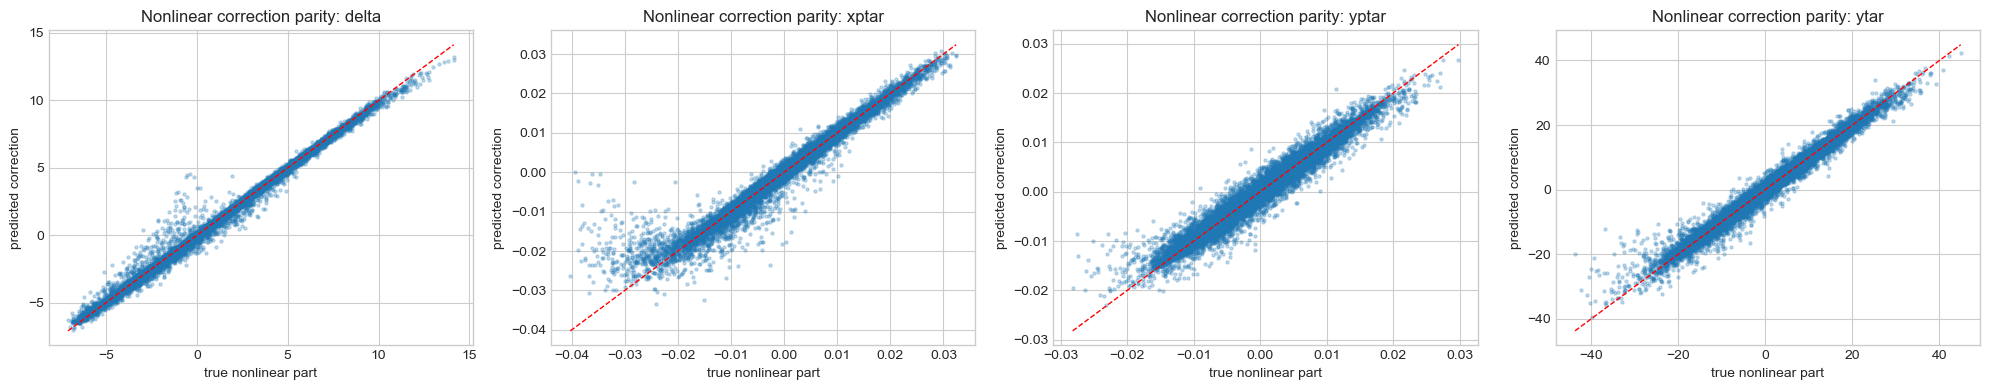

In [9]:
nonlinear_diag = None

if RUN_NONLINEAR_DIAGNOSTICS:
    diag_rows: list[dict[str, float | str]] = []
    x_val = result['X_val']

    for t_idx, t_name in enumerate(bundle.target_names):
        nonlinear_truth = result['y_true_nonlinear'][:, t_idx]
        nonlinear_pred = result['y_pred_correction'][:, t_idx]
        corr_truth_vs_pred = safe_corrcoef(nonlinear_truth, nonlinear_pred)

        for f_idx, feature_name in enumerate(bundle.feature_names):
            feature_values = x_val[:, f_idx]
            diag_rows.append({
                'target': t_name,
                'source': feature_name,
                'feature_corr_with_true_nonlinear': safe_corrcoef(feature_values, nonlinear_truth),
                'feature_corr_with_predicted_correction': safe_corrcoef(feature_values, nonlinear_pred),
                'true_vs_predicted_correction_corr': corr_truth_vs_pred,
            })

    nonlinear_diag = pd.DataFrame(diag_rows)
    display(nonlinear_diag.head(12))

    nt = len(bundle.target_names)
    fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
    if isinstance(axes, np.ndarray):
        axes_list = list(axes.ravel())
    else:
        axes_list = [axes]

    for i, t in enumerate(bundle.target_names):
        ax = axes_list[i]
        yt_corr = result['y_true_nonlinear'][:, i]
        yp_corr = result['y_pred_correction'][:, i]
        ax.scatter(yt_corr, yp_corr, s=5, alpha=0.25)
        lo = min(yt_corr.min(), yp_corr.min())
        hi = max(yt_corr.max(), yp_corr.max())
        ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
        ax.set_title(f'Nonlinear correction parity: {t}')
        ax.set_xlabel('true nonlinear part')
        ax.set_ylabel('predicted correction')

    plt.tight_layout()
    plt.show()
else:
    print('Skipping nonlinear diagnostics.')

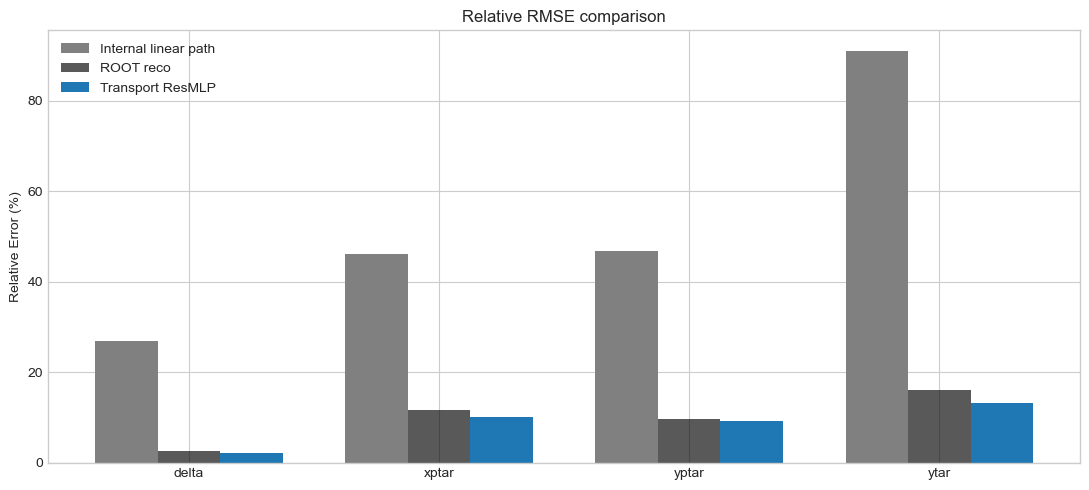

In [10]:
targets = bundle.target_names
linear_rel_rmse_pct = [100.0 * result['linear_rel_rmse'][i] for i in range(len(targets))]
resmlp_rel_rmse_pct = [100.0 * result['rel_rmse'][i] for i in range(len(targets))]
root_rel_rmse_pct = [100.0 * root_metrics['rel_rmse'][i] for i in range(len(targets))] if isinstance(root_metrics, dict) else None

x = np.arange(len(targets))
w = 0.25 if root_rel_rmse_pct is not None else 0.36

fig, ax = plt.subplots(figsize=(11, 5))
if root_rel_rmse_pct is not None:
    ax.bar(x - w, linear_rel_rmse_pct, width=w, label='Internal linear path', color='gray')
    ax.bar(x, root_rel_rmse_pct, width=w, label='ROOT reco', color='black', alpha=0.65)
    ax.bar(x + w, resmlp_rel_rmse_pct, width=w, label='Transport ResMLP', color='tab:blue')
else:
    ax.bar(x - w / 2, linear_rel_rmse_pct, width=w, label='Internal linear path', color='gray')
    ax.bar(x + w / 2, resmlp_rel_rmse_pct, width=w, label='Transport ResMLP', color='tab:blue')

ax.set_xticks(x)
ax.set_xticklabels(targets)
ax.set_title('Relative RMSE comparison')
ax.set_ylabel('Relative Error (%)')
ax.legend()
plt.tight_layout()
plt.show()

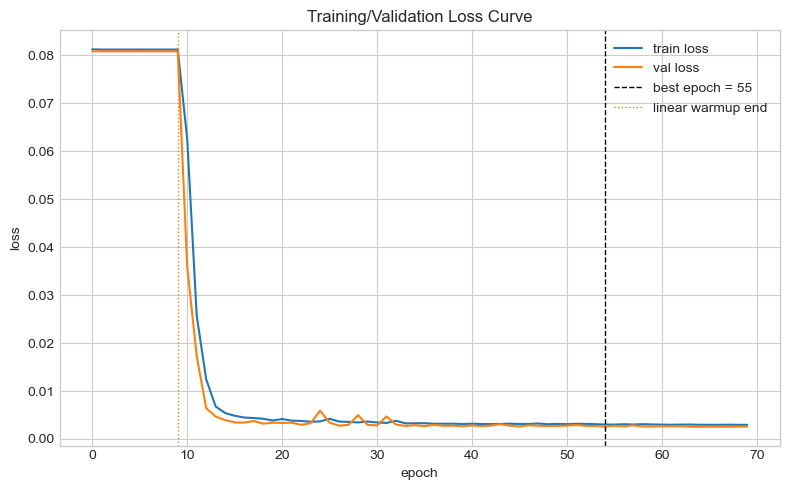

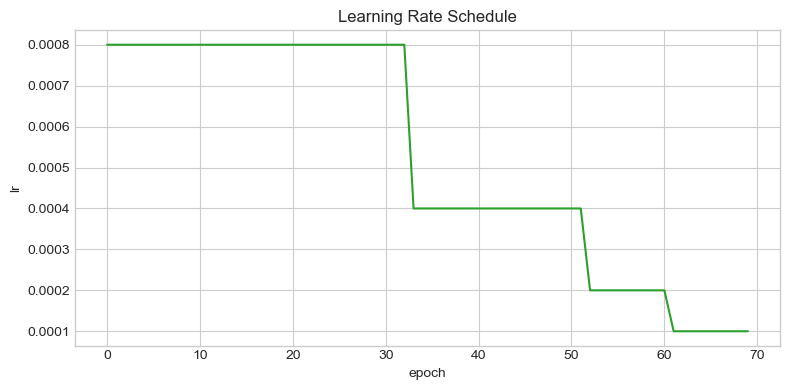

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(result['train_loss_hist'], label='train loss')
plt.plot(result['val_loss_hist'], label='val loss')
if result['best_epoch'] > 0:
    plt.axvline(result['best_epoch'] - 1, color='k', linestyle='--', linewidth=1, label=f"best epoch = {result['best_epoch']}")
if LINEAR_WARMUP_EPOCHS > 0:
    plt.axvline(LINEAR_WARMUP_EPOCHS - 1, color='tab:orange', linestyle=':', linewidth=1, label='linear warmup end')
plt.title('Training/Validation Loss Curve')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(result['lr_hist'], color='tab:green')
plt.title('Learning Rate Schedule')
plt.xlabel('epoch')
plt.ylabel('lr')
plt.tight_layout()
plt.show()

In [12]:
print('n_train               =', result['n_train'])
print('n_val                 =', result['n_val'])
print('best_epoch            =', result['best_epoch'])
print('best_val_loss         =', round(result['best_val_loss'], 6))
print('linear_rmse           =', np.round(result['linear_rmse'], 6).tolist())
print('transport_resmlp_rmse =', np.round(result['rmse'], 6).tolist())
if isinstance(root_metrics, dict):
    print('root_reco_rmse        =', np.round(root_metrics['rmse'], 6).tolist())
print('rmse_improve_vs_linear(%) =', np.round(result['rmse_improvement_vs_linear_pct'], 4).tolist())
print('correction_rmse       =', np.round(result['correction_rmse'], 6).tolist())
print('loss_weights          =', result['target_loss_weights'])

n_train               = 80000
n_val                 = 20000
best_epoch            = 55
best_val_loss         = 0.002586
linear_rmse           = [3.348368, 0.009156, 0.007472, 11.373461]
transport_resmlp_rmse = [0.278672, 0.002024, 0.001486, 1.653929]
root_reco_rmse        = [0.316723, 0.0023, 0.001544, 2.006163]
rmse_improve_vs_linear(%) = [91.6774, 77.8982, 80.1144, 85.458]
correction_rmse       = [0.278672, 0.002024, 0.001486, 1.653929]
loss_weights          = {'delta': 1.0, 'xptar': 1.0, 'yptar': 1.0, 'ytar': 0.5}


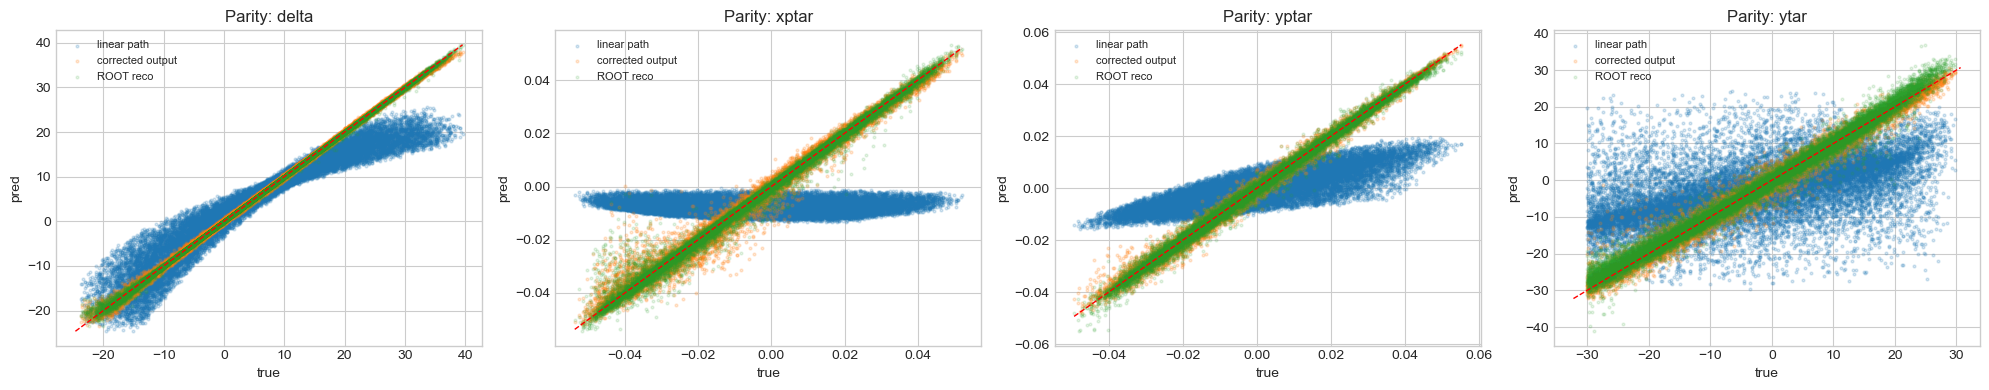

In [ ]:


y_true = result['y_true']
y_pred = result['y_pred']
y_linear = result['y_linear']
nt = y_true.shape[1]

fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
if isinstance(axes, np.ndarray):
    axes_list = list(axes.ravel())
else:
    axes_list = [axes]

for i, t in enumerate(bundle.target_names):
    ax = axes_list[i]
    yt = y_true[:, i]
    yl = y_linear[:, i]
    yp = y_pred[:, i]
    ax.scatter(yt, yl, s=4, alpha=0.18, label='linear path')
    ax.scatter(yt, yp, s=4, alpha=0.18, label='corrected output')
    if isinstance(root_metrics, dict):
        yroot = bundle.Y_reco[np.array(result['val_indices'], dtype=np.int64), i]
        ax.scatter(yt, yroot, s=4, alpha=0.12, label='ROOT reco')
    lo = min(yt.min(), yl.min(), yp.min())
    hi = max(yt.max(), yl.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(f'Parity: {t}')
    ax.set_xlabel('true')
    ax.set_ylabel('pred')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

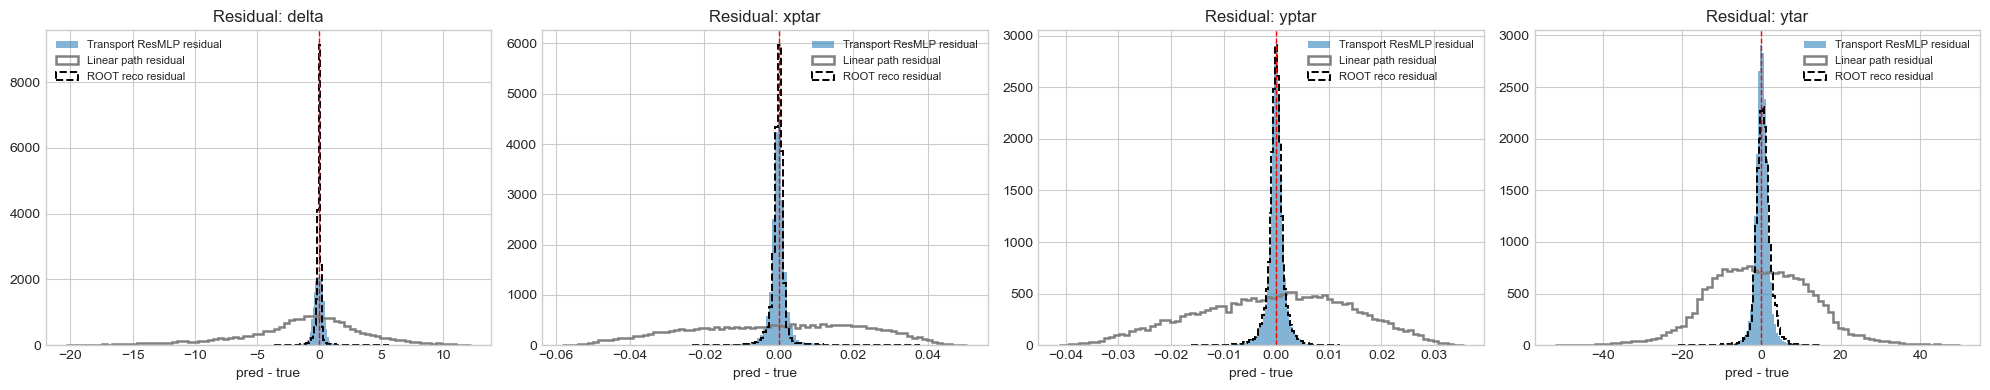

In [13]:
res_model = result['y_pred'] - result['y_true']
res_linear = result['y_linear'] - result['y_true']
res_root = bundle.Y_reco[np.array(result['val_indices'], dtype=np.int64)] - result['y_true']

nt = res_model.shape[1]
fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
if isinstance(axes, np.ndarray):
    axes_list = list(axes.ravel())
else:
    axes_list = [axes]

for i, t in enumerate(bundle.target_names):
    ax = axes_list[i]
    ax.hist(res_model[:, i], bins=80, alpha=0.55, label='Transport ResMLP residual')
    ax.hist(res_linear[:, i], bins=80, histtype='step', color='gray', linewidth=1.8, label='Linear path residual')
    rr = res_root[:, i]
    if np.any(np.isfinite(rr)):
        ax.hist(rr[np.isfinite(rr)], bins=80, histtype='step', color='k', linestyle='--', linewidth=1.4, label='ROOT reco residual')
    ax.axvline(0.0, color='r', linestyle='--', linewidth=1)
    ax.set_title(f'Residual: {t}')
    ax.set_xlabel('pred - true')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
mode = TARGET_MODE

metrics_json = OUTPUT_DIR / f'transport_resmlp_metrics_{mode}_{stamp}.json'
metrics_csv = OUTPUT_DIR / f'transport_resmlp_metrics_{mode}_{stamp}.csv'
plot_rmse = OUTPUT_DIR / f'transport_resmlp_rel_rmse_{mode}_{stamp}.png'
plot_parity = OUTPUT_DIR / f'transport_resmlp_parity_{mode}_{stamp}.png'
plot_resid = OUTPUT_DIR / f'transport_resmlp_residual_{mode}_{stamp}.png'
plot_loss = OUTPUT_DIR / f'transport_resmlp_loss_{mode}_{stamp}.png'
plot_diag = OUTPUT_DIR / f'transport_resmlp_nonlinear_diag_{mode}_{stamp}.png'

payload = {
    'root_file': str(ROOT_FILE.resolve()),
    'inp_file': str(INP_FILE.resolve()) if INP_FILE.exists() else None,
    'tree_name': TREE_NAME,
    'target_mode': TARGET_MODE,
    'feature_config': {
        'include_fry': INCLUDE_FRY,
        'fry_branch': FRY_BRANCH,
    },
    'feature_names': bundle.feature_names,
    'target_names': bundle.target_names,
    'target_truth_branches': bundle.target_truth_branches,
    'target_reco_branches': bundle.target_reco_branches,
    'max_events': MAX_EVENTS,
    'val_fraction': VAL_FRACTION,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'lr': LR,
    'weight_decay': WEIGHT_DECAY,
    'prefix': bundle.prefix,
    'p0_gev': P0,
    'model': {
        'hidden': MODEL_HIDDEN,
        'blocks': MODEL_BLOCKS,
        'dropout': DROPOUT,
        'linear_warmup_epochs': LINEAR_WARMUP_EPOCHS,
        'correction_l2_weight': CORRECTION_L2_WEIGHT,
    },
    'metrics': {
        'n_train': result['n_train'],
        'n_val': result['n_val'],
        'best_epoch': result['best_epoch'],
        'best_val_loss': result['best_val_loss'],
        'linear_rmse': result['linear_rmse'],
        'linear_mae': result['linear_mae'],
        'rmse': result['rmse'],
        'mae': result['mae'],
        'bias': result['bias'],
        'resid_std': result['resid_std'],
        'rel_rmse': result['rel_rmse'],
        'rel_mae': result['rel_mae'],
        'correction_rmse': result['correction_rmse'],
        'rmse_improvement_vs_linear_pct': result['rmse_improvement_vs_linear_pct'],
        'root_rmse': (root_metrics['rmse'].tolist() if isinstance(root_metrics, dict) else None),
        'root_mae': (root_metrics['mae'].tolist() if isinstance(root_metrics, dict) else None),
    },
    'nonlinear_diag_preview': (nonlinear_diag.head(20).to_dict(orient='records') if isinstance(nonlinear_diag, pd.DataFrame) else None),
}

with open(metrics_json, 'w', encoding='utf-8') as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

df_metrics.to_csv(metrics_csv, index=False)

# 保存 RMSE 对比图
targets = bundle.target_names
linear_rel_rmse_pct = [100.0 * result['linear_rel_rmse'][i] for i in range(len(targets))]
resmlp_rel_rmse_pct = [100.0 * result['rel_rmse'][i] for i in range(len(targets))]
root_rel_rmse_pct = [100.0 * root_metrics['rel_rmse'][i] for i in range(len(targets))] if isinstance(root_metrics, dict) else None
x = np.arange(len(targets))
w = 0.25 if root_rel_rmse_pct is not None else 0.36
fig, ax = plt.subplots(figsize=(11, 5))
if root_rel_rmse_pct is not None:
    ax.bar(x - w, linear_rel_rmse_pct, width=w, label='Internal linear path', color='gray')
    ax.bar(x, root_rel_rmse_pct, width=w, label='ROOT reco', color='black', alpha=0.65)
    ax.bar(x + w, resmlp_rel_rmse_pct, width=w, label='Transport ResMLP', color='tab:blue')
else:
    ax.bar(x - w / 2, linear_rel_rmse_pct, width=w, label='Internal linear path', color='gray')
    ax.bar(x + w / 2, resmlp_rel_rmse_pct, width=w, label='Transport ResMLP', color='tab:blue')
ax.set_xticks(x)
ax.set_xticklabels(targets)
ax.set_title('Relative RMSE comparison')
ax.set_ylabel('Relative Error (%)')
ax.legend()
plt.tight_layout()
plt.savefig(plot_rmse, dpi=150)
plt.close(fig)

# 保存 loss 图
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(result['train_loss_hist'], label='train loss')
ax.plot(result['val_loss_hist'], label='val loss')
if result['best_epoch'] > 0:
    ax.axvline(result['best_epoch'] - 1, color='k', linestyle='--', linewidth=1, label=f"best epoch = {result['best_epoch']}")
if LINEAR_WARMUP_EPOCHS > 0:
    ax.axvline(LINEAR_WARMUP_EPOCHS - 1, color='tab:orange', linestyle=':', linewidth=1, label='linear warmup end')
ax.set_title('Training/Validation Loss Curve')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.legend()
plt.tight_layout()
plt.savefig(plot_loss, dpi=150)
plt.close(fig)

# 保存 parity 图
y_true = result['y_true']
y_pred = result['y_pred']
y_linear = result['y_linear']
nt = y_true.shape[1]
fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
axes_list = list(axes.ravel()) if isinstance(axes, np.ndarray) else [axes]
for i, t in enumerate(bundle.target_names):
    ax = axes_list[i]
    yt = y_true[:, i]
    yl = y_linear[:, i]
    yp = y_pred[:, i]
    ax.scatter(yt, yl, s=4, alpha=0.18, label='linear path')
    ax.scatter(yt, yp, s=4, alpha=0.18, label='corrected output')
    if isinstance(root_metrics, dict):
        yroot = bundle.Y_reco[np.array(result['val_indices'], dtype=np.int64), i]
        ax.scatter(yt, yroot, s=4, alpha=0.12, label='ROOT reco')
    lo = min(yt.min(), yl.min(), yp.min())
    hi = max(yt.max(), yl.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(f'Parity: {t}')
    ax.set_xlabel('true')
    ax.set_ylabel('pred')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(plot_parity, dpi=150)
plt.close(fig)

# 保存 residual 图
res_model = result['y_pred'] - result['y_true']
res_linear = result['y_linear'] - result['y_true']
res_root = bundle.Y_reco[np.array(result['val_indices'], dtype=np.int64)] - result['y_true']
nt = res_model.shape[1]
fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
axes_list = list(axes.ravel()) if isinstance(axes, np.ndarray) else [axes]
for i, t in enumerate(bundle.target_names):
    ax = axes_list[i]
    ax.hist(res_model[:, i], bins=80, alpha=0.55, label='Transport ResMLP residual')
    ax.hist(res_linear[:, i], bins=80, histtype='step', color='gray', linewidth=1.8, label='Linear path residual')
    rr = res_root[:, i]
    if np.any(np.isfinite(rr)):
        ax.hist(rr[np.isfinite(rr)], bins=80, histtype='step', color='k', linestyle='--', linewidth=1.4, label='ROOT reco residual')
    ax.axvline(0.0, color='r', linestyle='--', linewidth=1)
    ax.set_title(f'Residual: {t}')
    ax.set_xlabel('pred - true')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(plot_resid, dpi=150)
plt.close(fig)

# 保存非线性 correction parity 图
fig, axes = plt.subplots(1, len(bundle.target_names), figsize=(5 * len(bundle.target_names), 4))
axes_list = list(axes.ravel()) if isinstance(axes, np.ndarray) else [axes]
for i, t in enumerate(bundle.target_names):
    ax = axes_list[i]
    yt_corr = result['y_true_nonlinear'][:, i]
    yp_corr = result['y_pred_correction'][:, i]
    ax.scatter(yt_corr, yp_corr, s=5, alpha=0.25)
    lo = min(yt_corr.min(), yp_corr.min())
    hi = max(yt_corr.max(), yp_corr.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(f'Nonlinear correction: {t}')
    ax.set_xlabel('true nonlinear part')
    ax.set_ylabel('predicted correction')
plt.tight_layout()
plt.savefig(plot_diag, dpi=150)
plt.close(fig)

print('Saved:')
print('-', metrics_json.resolve())
print('-', metrics_csv.resolve())
print('-', plot_rmse.resolve())
print('-', plot_loss.resolve())
print('-', plot_parity.resolve())
print('-', plot_resid.resolve())
print('-', plot_diag.resolve())

Saved:
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\ResMLP\outputs_transport_skip\transport_resmlp_metrics_all_20260410_210921.json
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\ResMLP\outputs_transport_skip\transport_resmlp_metrics_all_20260410_210921.csv
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\ResMLP\outputs_transport_skip\transport_resmlp_rel_rmse_all_20260410_210921.png
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\ResMLP\outputs_transport_skip\transport_resmlp_loss_all_20260410_210921.png
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\ResMLP\outputs_transport_skip\transport_resmlp_parity_all_20260410_210921.png
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\ResMLP\outputs_transport_skip\transport_resmlp_residual_all_20260410_210921.png
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\ResMLP\outputs_transpor

: 